<a href="https://colab.research.google.com/github/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# Clustering and Dimensionality Reduction Assignment
# Dataset: Wine Dataset
# =========================================================

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset
wine = load_wine()

# Create DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Display first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [2]:
# Check dataset shape and info
print("Shape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaled data shape:", X_scaled.shape)

Shape of dataset: (178, 13)

Missing values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Duplicate rows: 0
Scaled data shape: (178, 13)


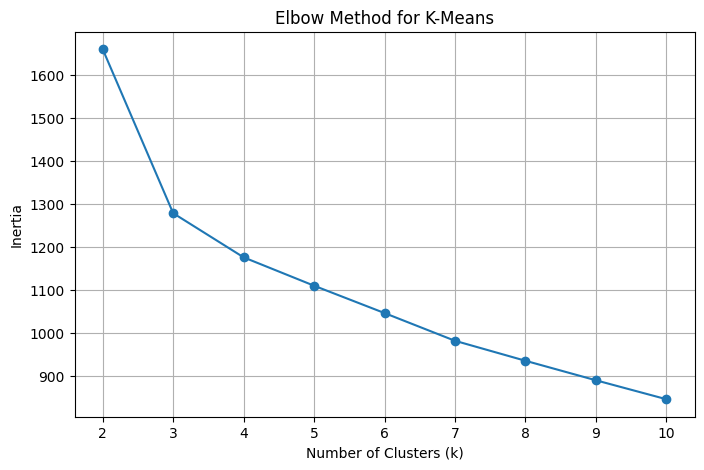

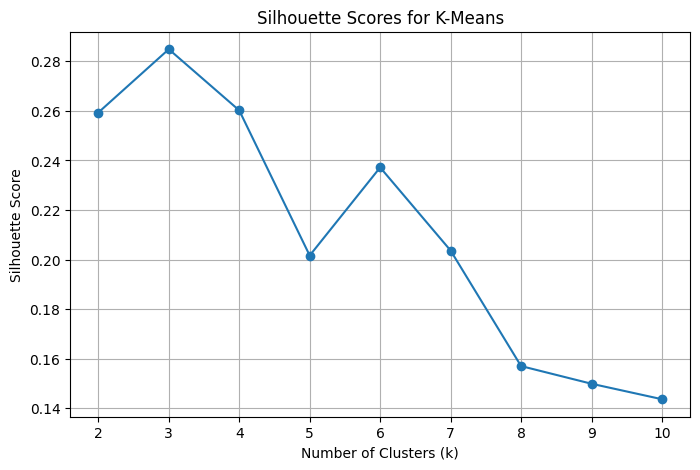

Best number of clusters for K-Means based on silhouette score: 3


In [3]:
# =========================================================
# Find optimal number of clusters for K-Means
# =========================================================

inertia = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow Method
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Scores for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(sil_scores)]
print("Best number of clusters for K-Means based on silhouette score:", best_k)

In [4]:
# Apply K-Means with best_k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))

K-Means Silhouette Score: 0.2849


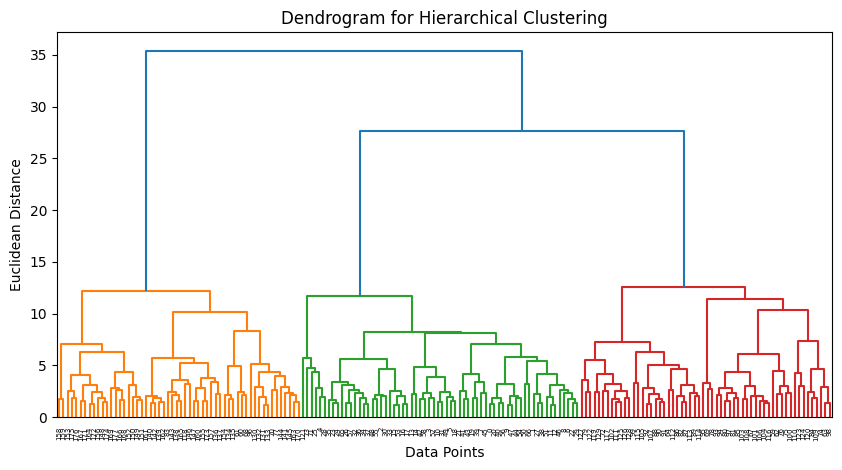

In [5]:
# =========================================================
# Hierarchical Clustering
# =========================================================

# Dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

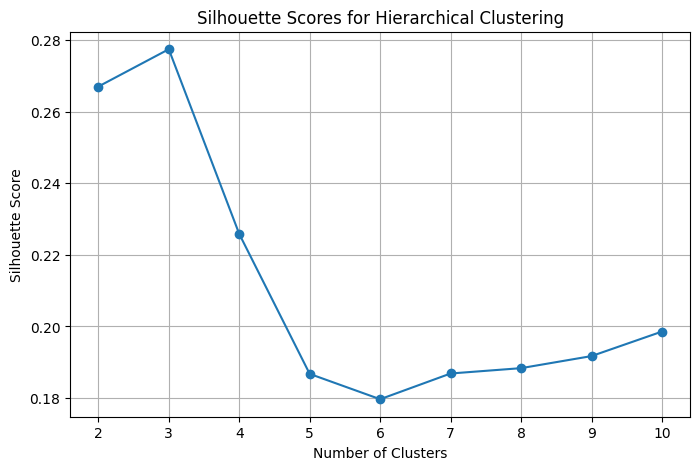

Best number of clusters for Hierarchical Clustering: 3


In [6]:
# Test silhouette scores for hierarchical clustering
hier_sil_scores = []

for k in k_values:
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    hier_sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_values, hier_sil_scores, marker='o')
plt.title("Silhouette Scores for Hierarchical Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_hier_k = k_values[np.argmax(hier_sil_scores)]
print("Best number of clusters for Hierarchical Clustering:", best_hier_k)

In [7]:
# Apply Hierarchical Clustering with best_hier_k
hierarchical = AgglomerativeClustering(n_clusters=best_hier_k, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

hier_silhouette = silhouette_score(X_scaled, hier_labels)
print("Hierarchical Clustering Silhouette Score:", round(hier_silhouette, 4))

Hierarchical Clustering Silhouette Score: 0.2774


In [8]:
# =========================================================
# Dimensionality Reduction using PCA
# =========================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.36198848 0.1920749 ]
Total Explained Variance: 0.5540633835693526


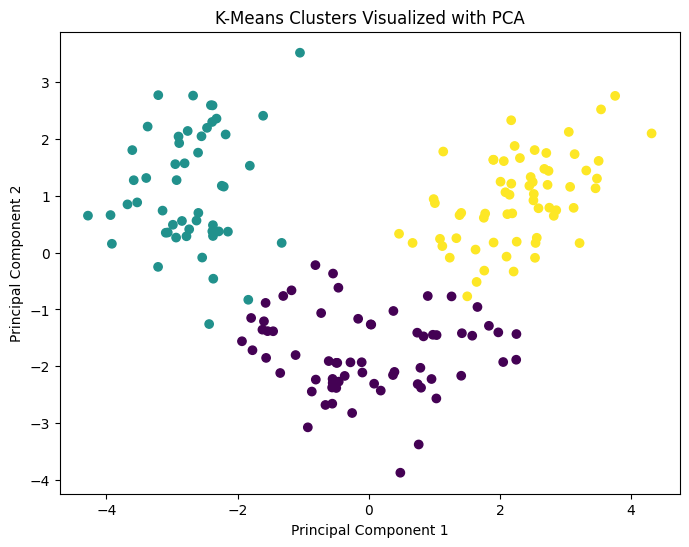

In [9]:
# Visualize K-Means clusters with PCA
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

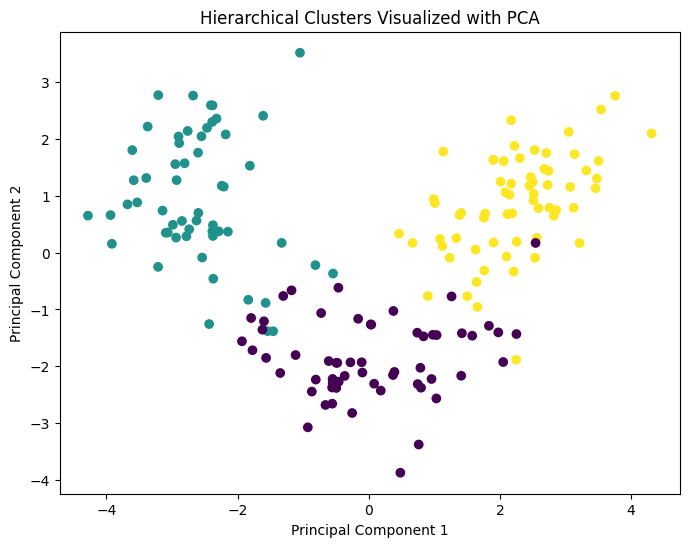

In [10]:
# Visualize Hierarchical clusters with PCA
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels)
plt.title("Hierarchical Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

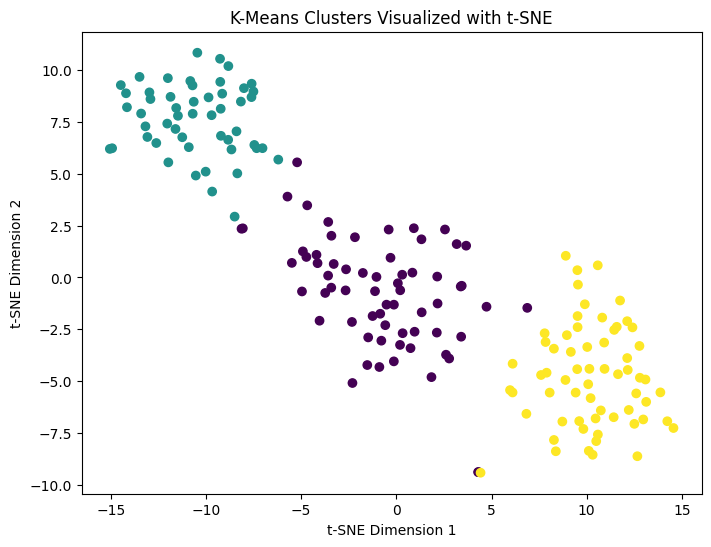

In [11]:
# =========================================================
# Dimensionality Reduction using t-SNE
# =========================================================

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels)
plt.title("K-Means Clusters Visualized with t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

In [12]:
# =========================================================
# Compare model performance
# =========================================================

results = pd.DataFrame({
    "Model": ["K-Means", "Hierarchical Clustering"],
    "Best Number of Clusters": [best_k, best_hier_k],
    "Silhouette Score": [kmeans_silhouette, hier_silhouette]
})

results

# Print final interpretation
best_model = "K-Means" if kmeans_silhouette > hier_silhouette else "Hierarchical Clustering"

print("Best performing model:", best_model)
print("\nInterpretation:")
print("- The Wine dataset was standardized before clustering because clustering methods are sensitive to feature scale.")
print("- PCA reduced the dataset to two dimensions for visualization while preserving most of the important variance.")
print("- t-SNE provided another low-dimensional view of the clusters.")
print("- The model with the higher silhouette score is considered the better clustering model for this dataset.")

Best performing model: K-Means

Interpretation:
- The Wine dataset was standardized before clustering because clustering methods are sensitive to feature scale.
- PCA reduced the dataset to two dimensions for visualization while preserving most of the important variance.
- t-SNE provided another low-dimensional view of the clusters.
- The model with the higher silhouette score is considered the better clustering model for this dataset.


## Interpretation of Results

The Wine dataset was selected because it is suitable for clustering and dimensionality reduction. It contains only numerical variables, so one-hot encoding was not required. The dataset also had no missing values or duplicate rows, which simplified preprocessing.

Standardization was applied because clustering algorithms such as K-Means and Hierarchical Clustering are sensitive to differences in feature scale.

For clustering, K-Means and Hierarchical Clustering were implemented. The optimal number of clusters was determined using the Elbow Method and Silhouette Score. The silhouette score was used as the main evaluation metric because it measures how well data points fit within their assigned clusters compared to other clusters.

For dimensionality reduction, PCA was used to reduce the feature space to two dimensions for visualization. t-SNE was also applied to provide an alternative low-dimensional representation of the data.

Based on the silhouette scores, the best-performing model was selected. The visualizations showed that the dataset contains meaningful groupings, and dimensionality reduction helped make those clusters easier to interpret.

## Links:

- Colab notebook link: https://colab.research.google.com/drive/1yHYldtz4ogKPKVsx7BMgzbLp4V4khE0P?usp=sharing
- GitHub repository link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment9.ipynb
- GitHub repository README link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/README1.md